# Notebook 13 — Individual Comparisons

> **Supplementary §14**

This notebook uses heatmaps to visualise detailed temporal and fine-scale changes in the morphing shape modes across experimental conditions and individuals. Each morphing mode score is represented as a row, with conditions stacked for comparison.

The heatmaps are scaled to the 1st and 99th percentiles of each mode's score distribution: blue indicates negative scores, red indicates positive scores, and yellow indicates values near the mean hawk shape.

These heatmaps provide a closer look at individual flight behaviour for consistent behaviours. As within- and across-individual variation is high, they do not represent stereotyped generalisable behaviours — more advanced methods would be required for quantitative comparison across individuals with variable wingbeat frequencies.

## Contents
1. [Setup and data loading](#setup)
2. [Heatmap comparisons — obstacle flights](#obstacle-heatmaps)
3. [Heatmap comparisons — weight effect](#weight-heatmaps)
4. [Heatmap comparisons — naive vs experienced](#naive-heatmaps)
5. [Summary](#summary)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from kinematic_morphospace import (
    filter_by, run_PCA,
    get_score_df,
)
from kinematic_morphospace.plotting import (
    prepare_heatmap_comparison, plot_difference_PC_scores_heatmap,
    plot_difference_exp_scores_heatmap,
)

## Load Data and Prepare Scores

In [2]:
unilateral_data = np.load("../../data/processed/unilateral_data.npy")
unilateral_frame_info_df = pd.read_csv("../../data/processed/unilateral_frame_info_df.csv")

filt = filter_by(unilateral_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(unilateral_data[filt], unilateral_data)

scores_df, horz_dist_bins = get_score_df(scores, unilateral_frame_info_df, size_bin=0.07)

# Negate PC07 (m-folding) for interpretability: positive = more folded
scores_df["PC07"] = -scores_df["PC07"]

PC_cols = [f'PC{i:02}' for i in range(1, 10)]

# Move PC08 (collective pitching) after PC05 (counter pitching) to group
# related pitching modes together for easier visual comparison
PC_cols.insert(5, PC_cols.pop(7))

print(f"Total frames: {scores.shape[0]:,}")
print(f"Scores dataframe: {scores_df.shape}")
print(f"Mode order: {PC_cols}")

Total frames: 289,528
Scores dataframe: (289528, 27)
Mode order: ['PC01', 'PC02', 'PC03', 'PC04', 'PC05', 'PC08', 'PC06', 'PC07', 'PC09']


## Heatmap Comparisons — Obstacle Flights

Comparing control and obstacle flights for individual hawks. The upper row of each heatmap shows the obstacle condition; the lower row shows the control. The vertical marker indicates the obstacle position (−4.5 m from the landing perch). Flights with added weight (IMU) are excluded.

### Colour interpretation

The heatmaps are scaled to the 1st and 99th percentiles of each morphing mode's score distribution:
- **Blue** — negative scores (e.g., wings lowered, contracted, or swept back relative to the mean)
- **Red** — positive scores (e.g., wings raised, spread, or swept forward relative to the mean)
- **Yellow** — values near the mean hawk shape

Condition 1: Number of frames: 18092; Number of flights: 50
Condition 2: Number of frames: 7896; Number of flights: 33
--- Toothless ---


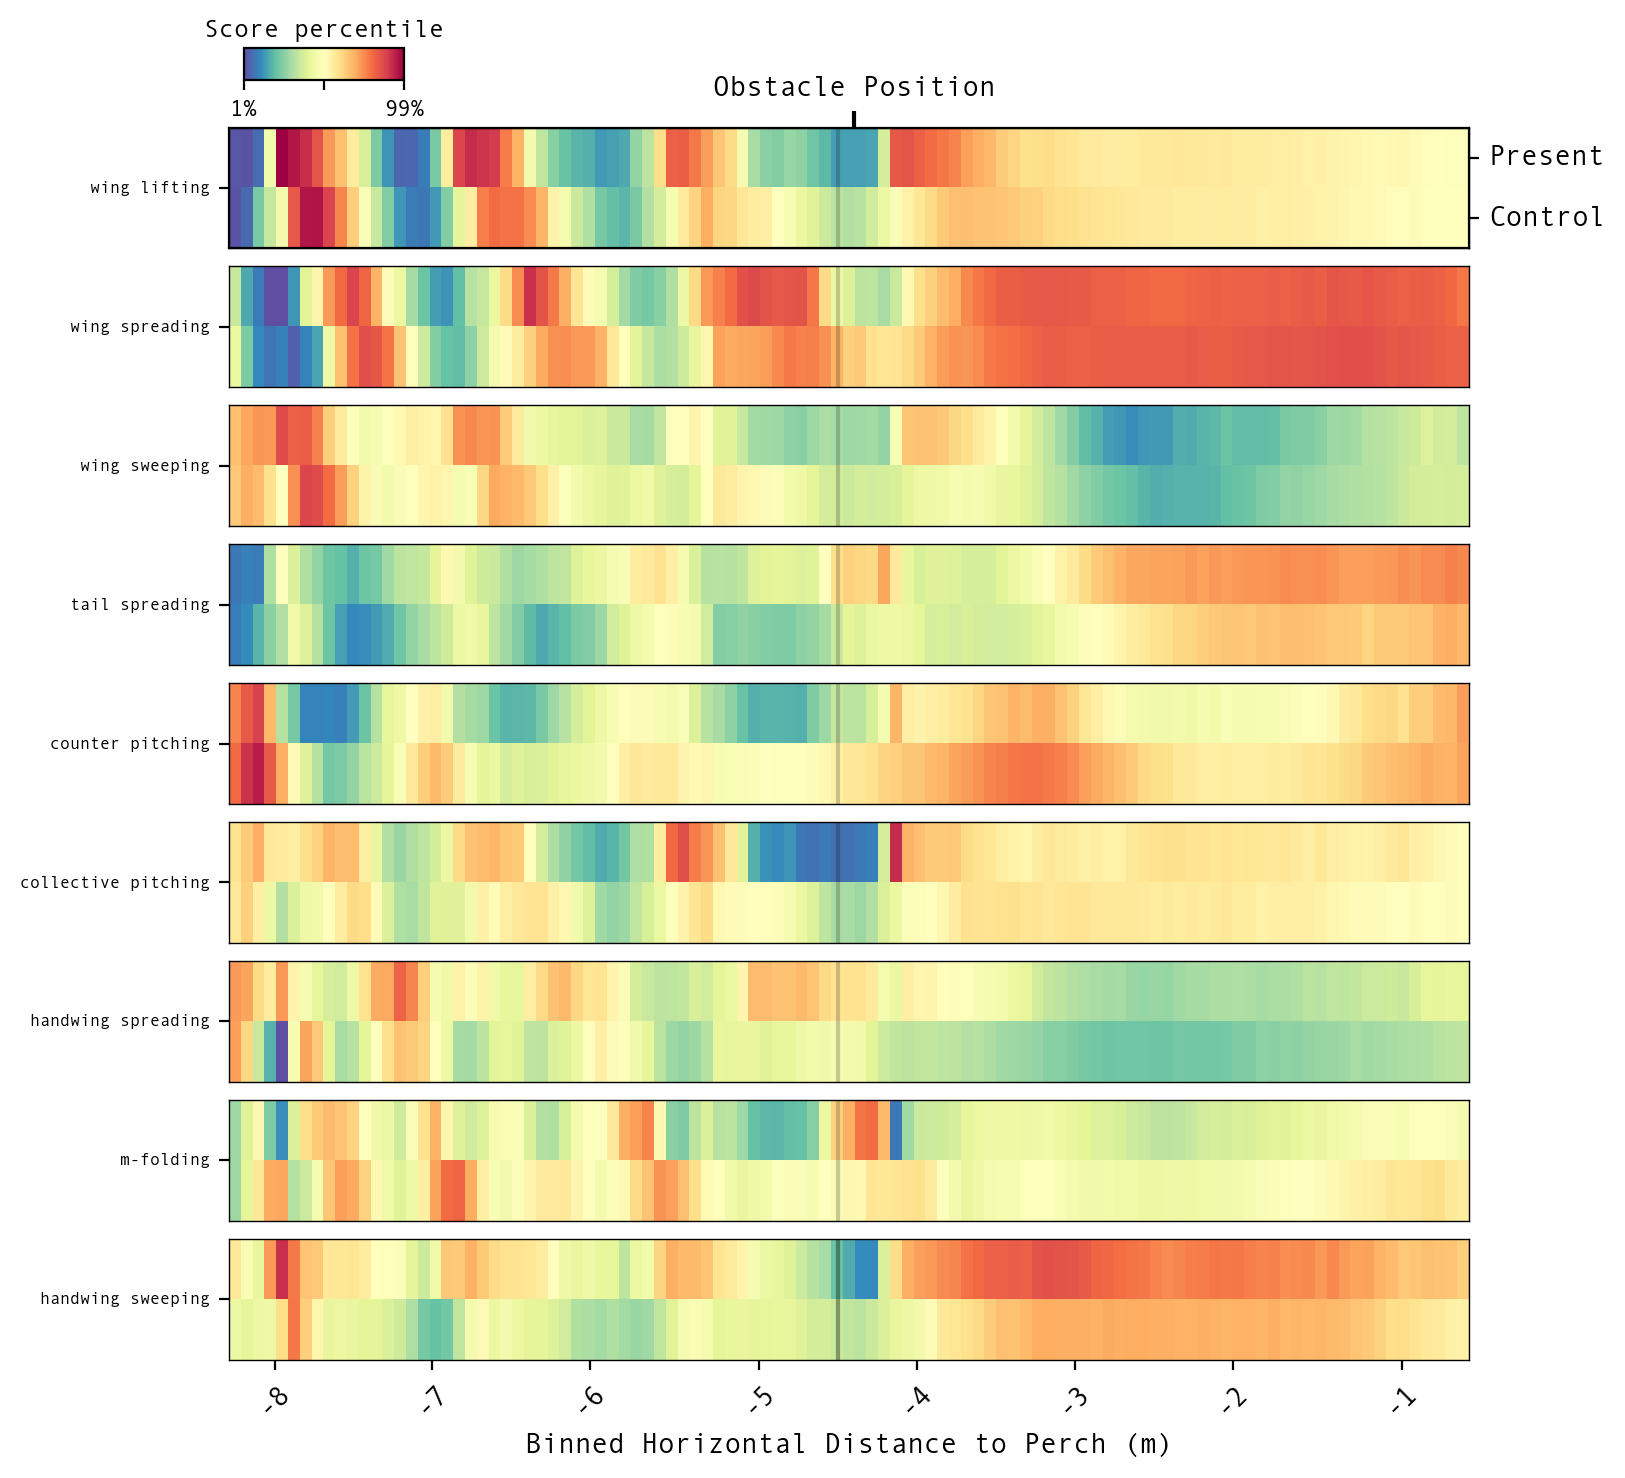

Condition 1: Number of frames: 11136; Number of flights: 48
Condition 2: Number of frames: 4998; Number of flights: 32
--- Ruby ---


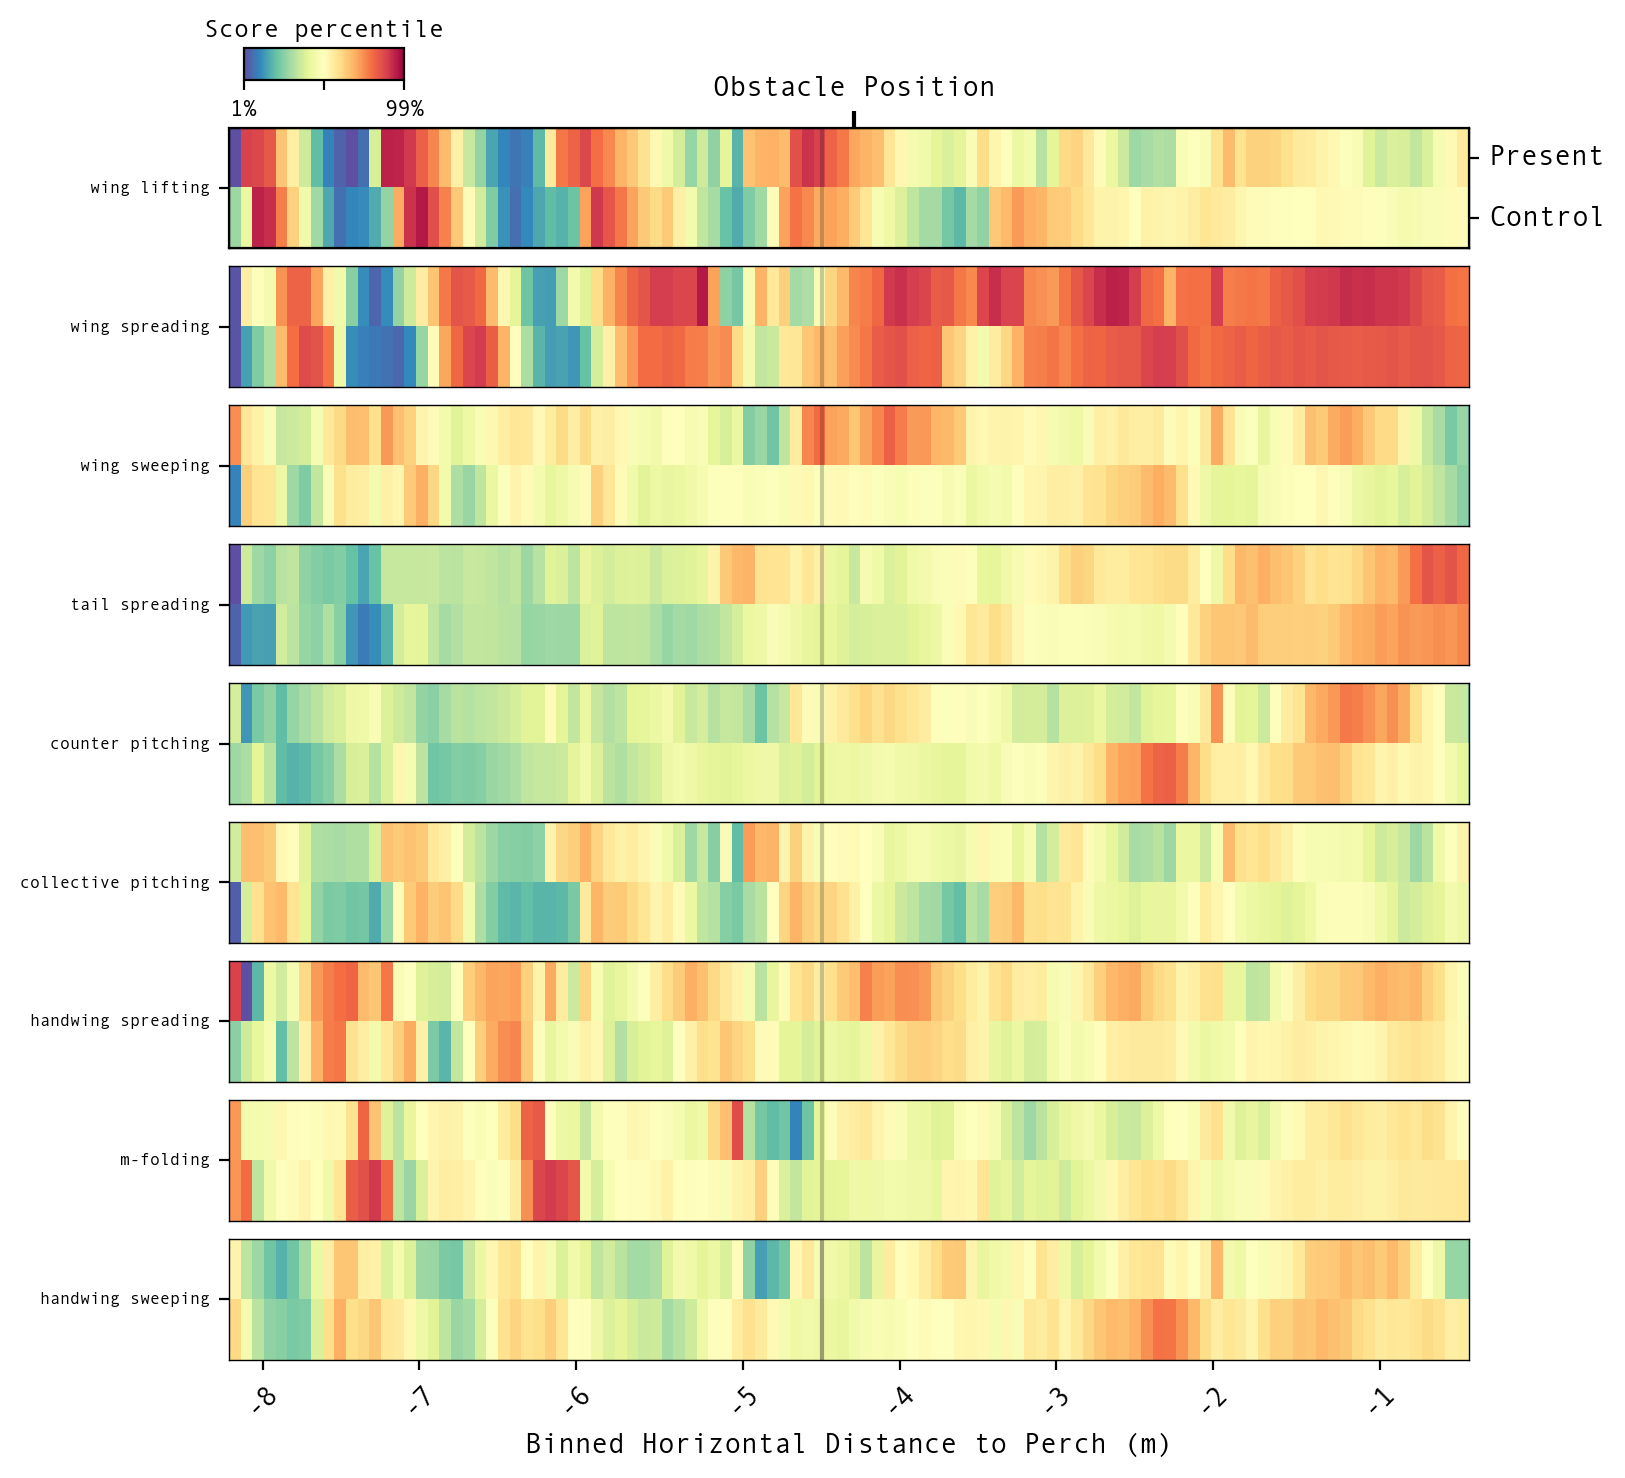

In [3]:
plt.close("all")
# hawks = ["Drogon", "Toothless", "Charmander", "Ruby"]
hawks = ["Toothless", "Ruby"]

for hawk in hawks:
    control_df, obstacle_df, score_5, score_95 = prepare_heatmap_comparison(
        scores_df,
        reference_filters={"hawkname": hawk, "year": 2020},
        condition1={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": hawk, "IMU": 0},
        condition2={"obstacle": 1, "perchDist": 9, "year": 2020, "hawkname": hawk, "IMU": 0},
    )
    print(f"--- {hawk} ---")
    plot_difference_PC_scores_heatmap(control_df, obstacle_df, PC_cols, score_5, score_95)

## Heatmap Comparisons — Weight Effect

Comparing flights with and without an added weight (IMU) for individual hawks. The upper row shows the weighted condition; the lower row shows the control.

Condition 1: Number of frames: 8906; Number of flights: 45
Condition 2: Number of frames: 2750; Number of flights: 16
--- Charmander: weight vs control ---


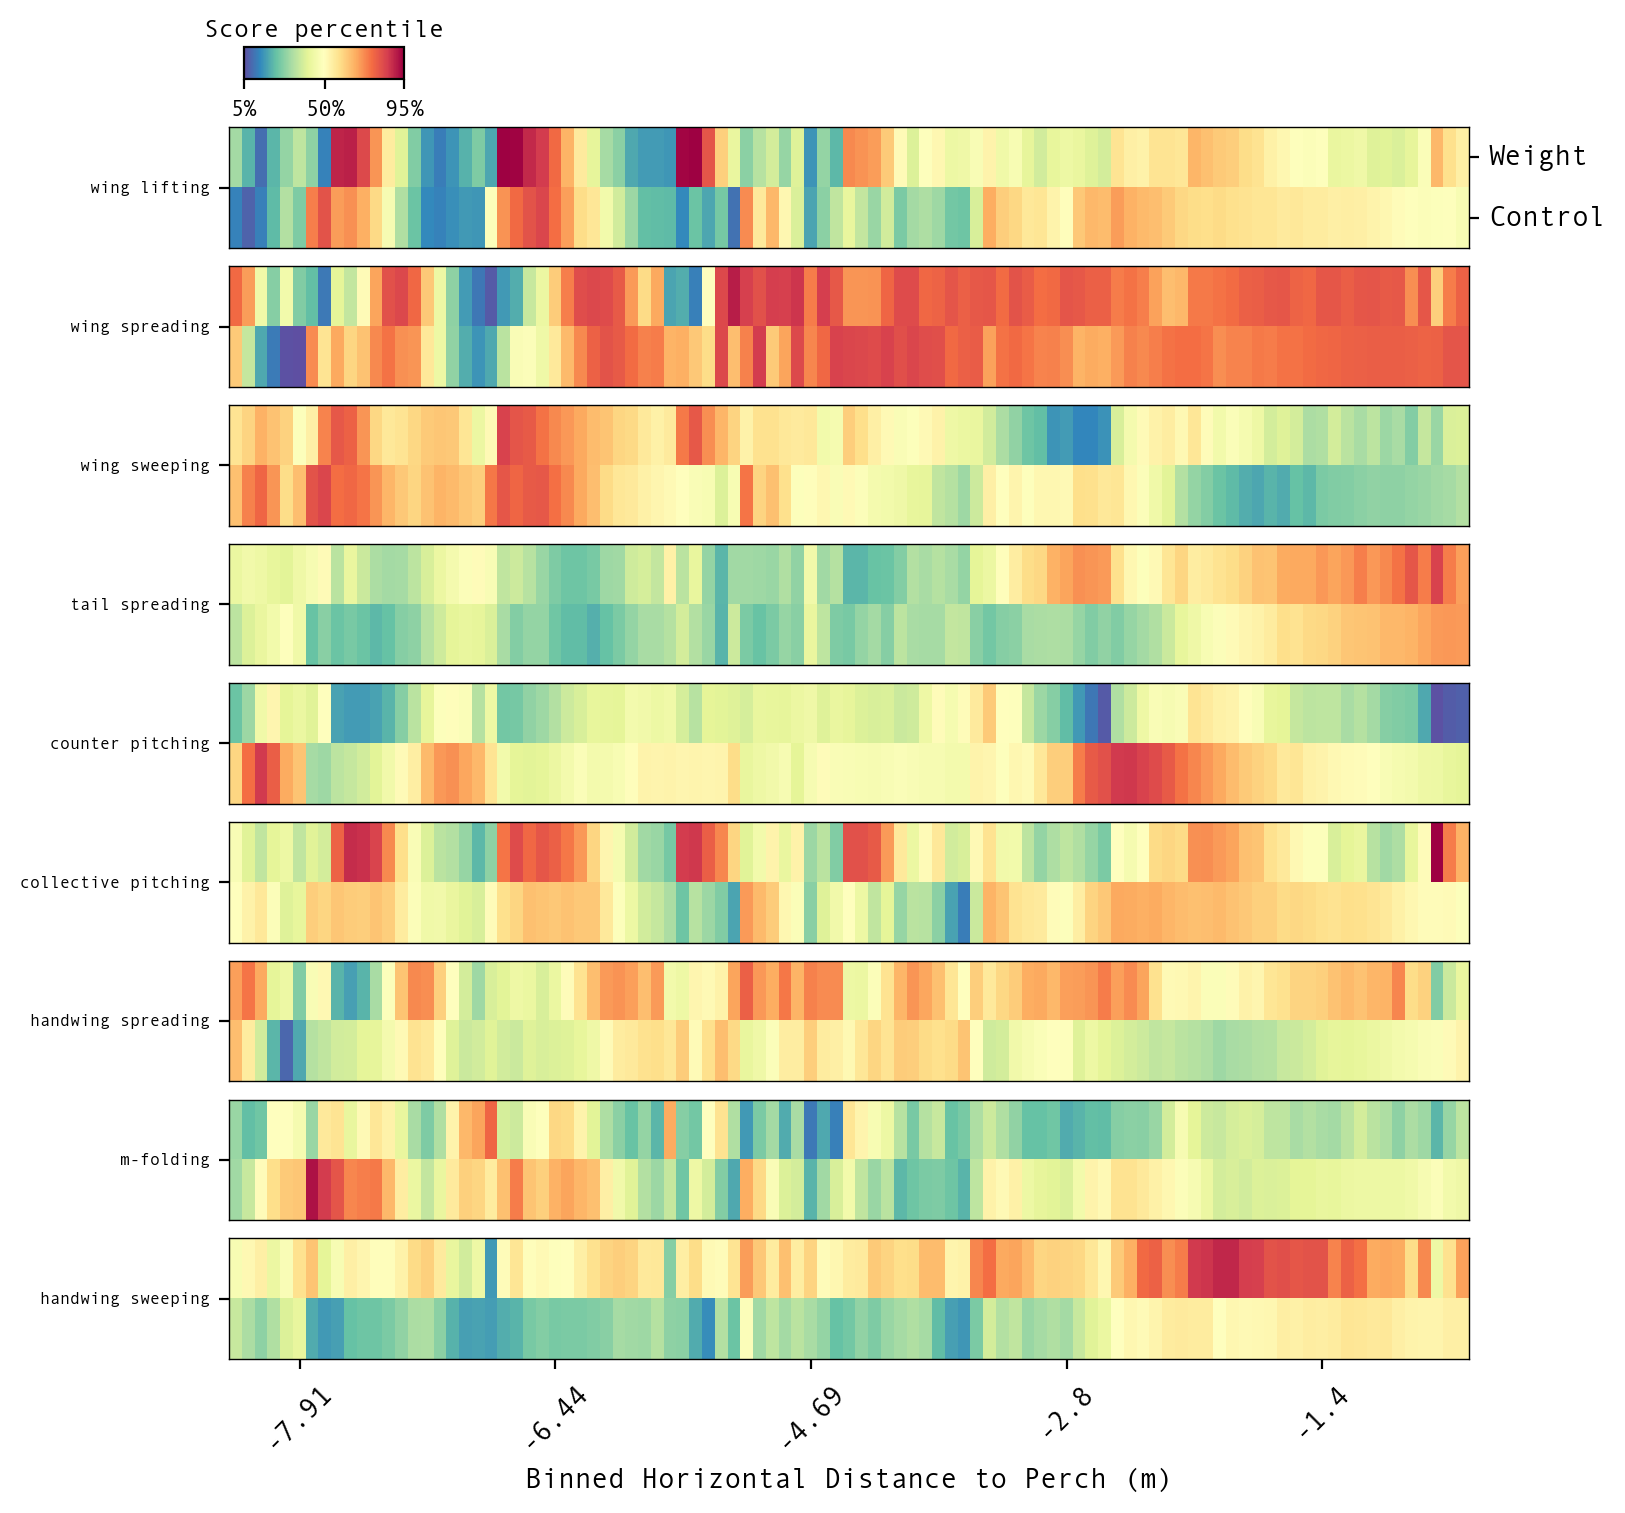

Condition 1: Number of frames: 11136; Number of flights: 48
Condition 2: Number of frames: 4394; Number of flights: 18
--- Ruby: weight vs control ---


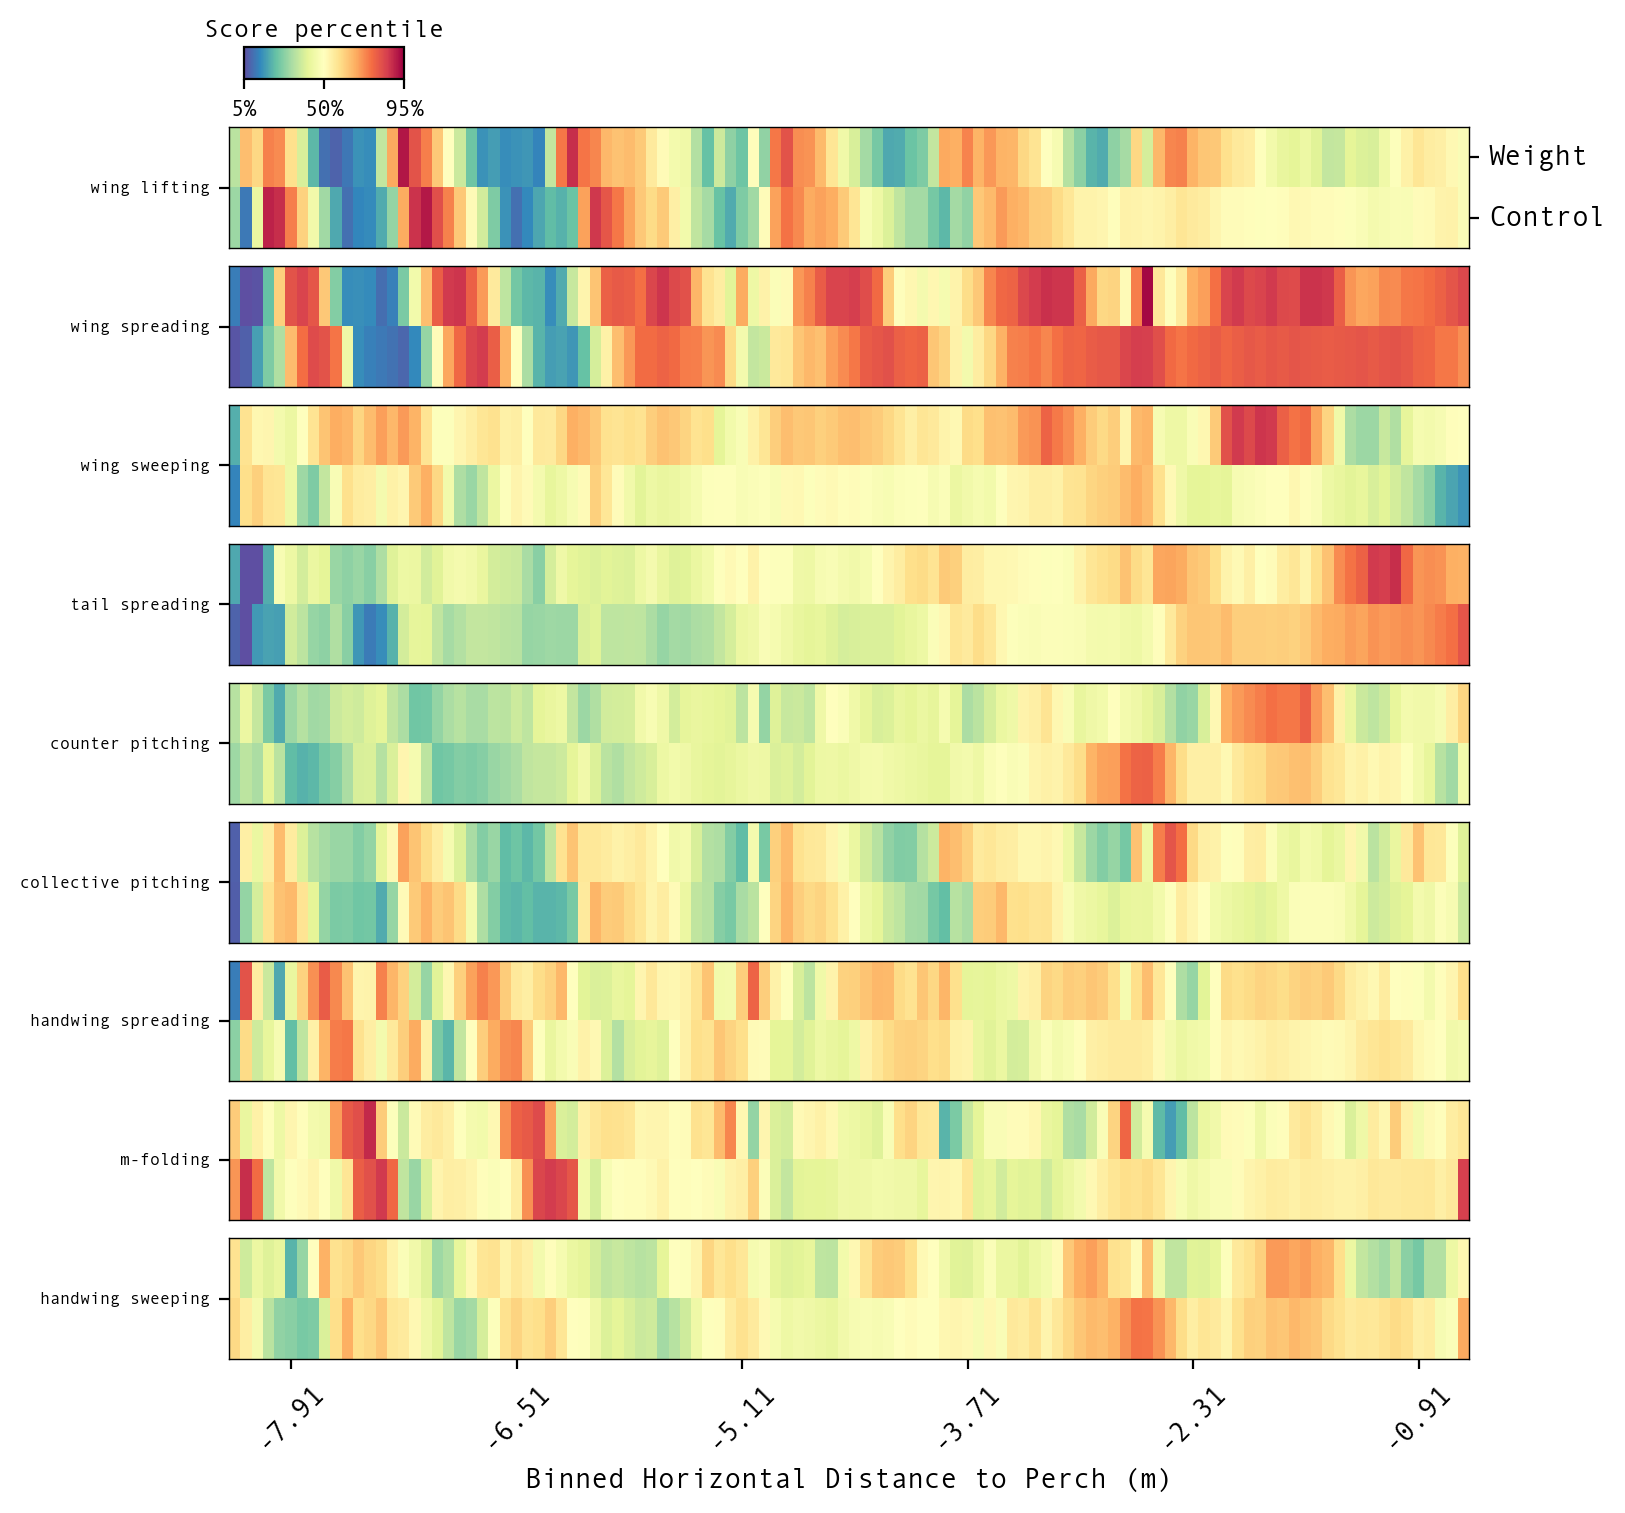

In [4]:
plt.close("all")
hawks = ["Charmander", "Ruby"]

for hawk in hawks:
    control_df, weight_df, score_5, score_95 = prepare_heatmap_comparison(
        scores_df,
        reference_filters={"hawkname": hawk, "year": 2020},
        condition1={"obstacle": 0, "perchDist": 9, "year": 2020, "IMU": 0, "hawkname": hawk},
        condition2={"obstacle": 0, "perchDist": 9, "year": 2020, "IMU": 1, "hawkname": hawk},
    )
    print(f"--- {hawk}: weight vs control ---")
    plot_difference_exp_scores_heatmap(
        control_df, "Control", weight_df, "Weight", PC_cols, score_5, score_95
    )

## Heatmap Comparisons — Naive vs Experienced

Two hawks (Drogon, Toothless) were recorded as both naive juveniles (2017) and experienced adults (2020). The comparison reveals how flight morphing patterns change with experience.

Condition 1: Number of frames: 14550; Number of flights: 76
Condition 2: Number of frames: 7312; Number of flights: 46
--- Drogon: naive vs experienced ---


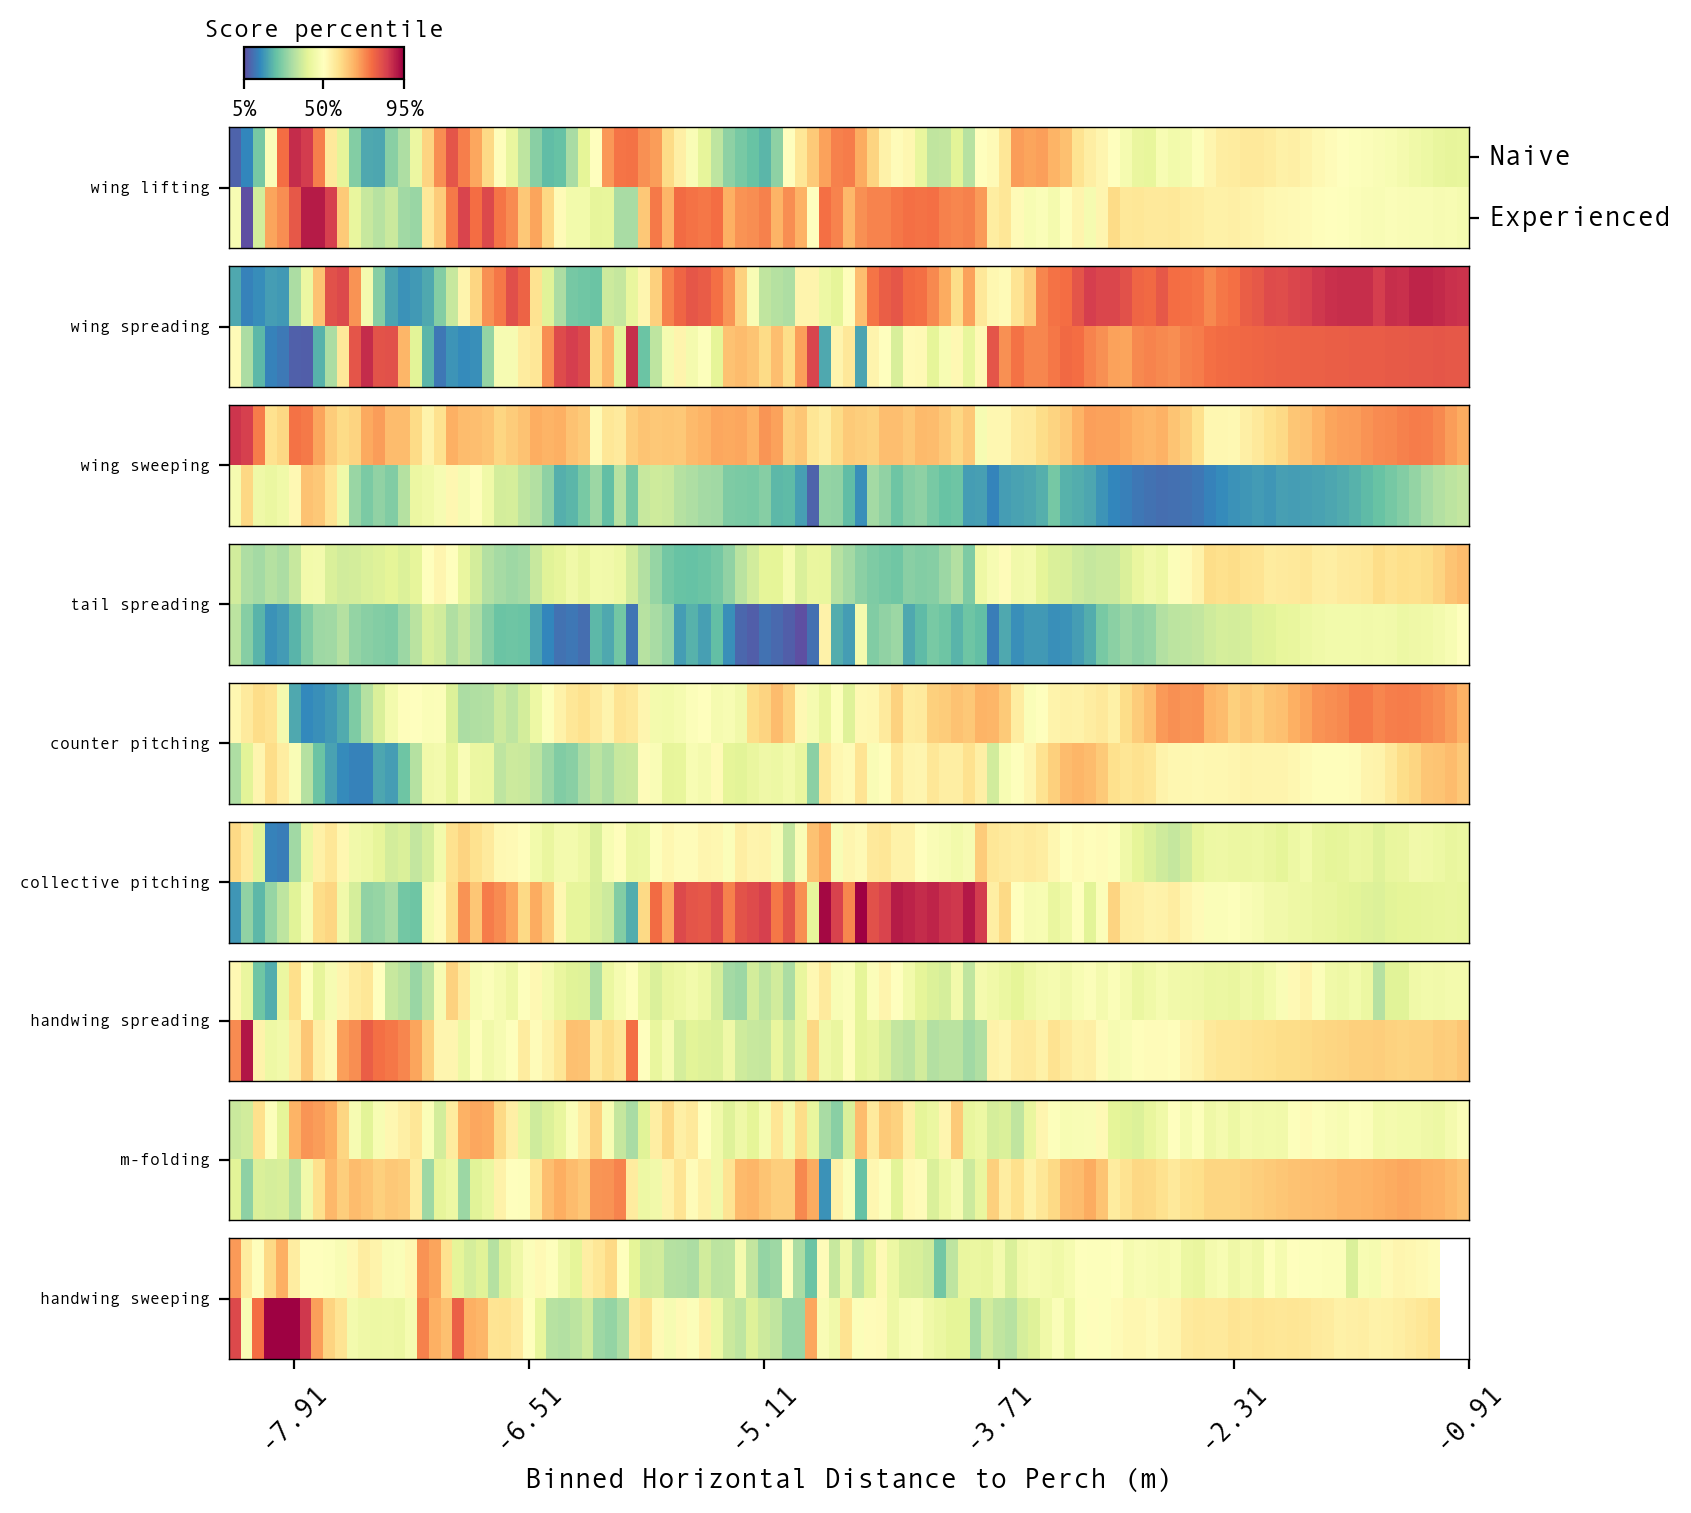

Condition 1: Number of frames: 14778; Number of flights: 58
Condition 2: Number of frames: 18092; Number of flights: 50
--- Toothless: naive vs experienced ---


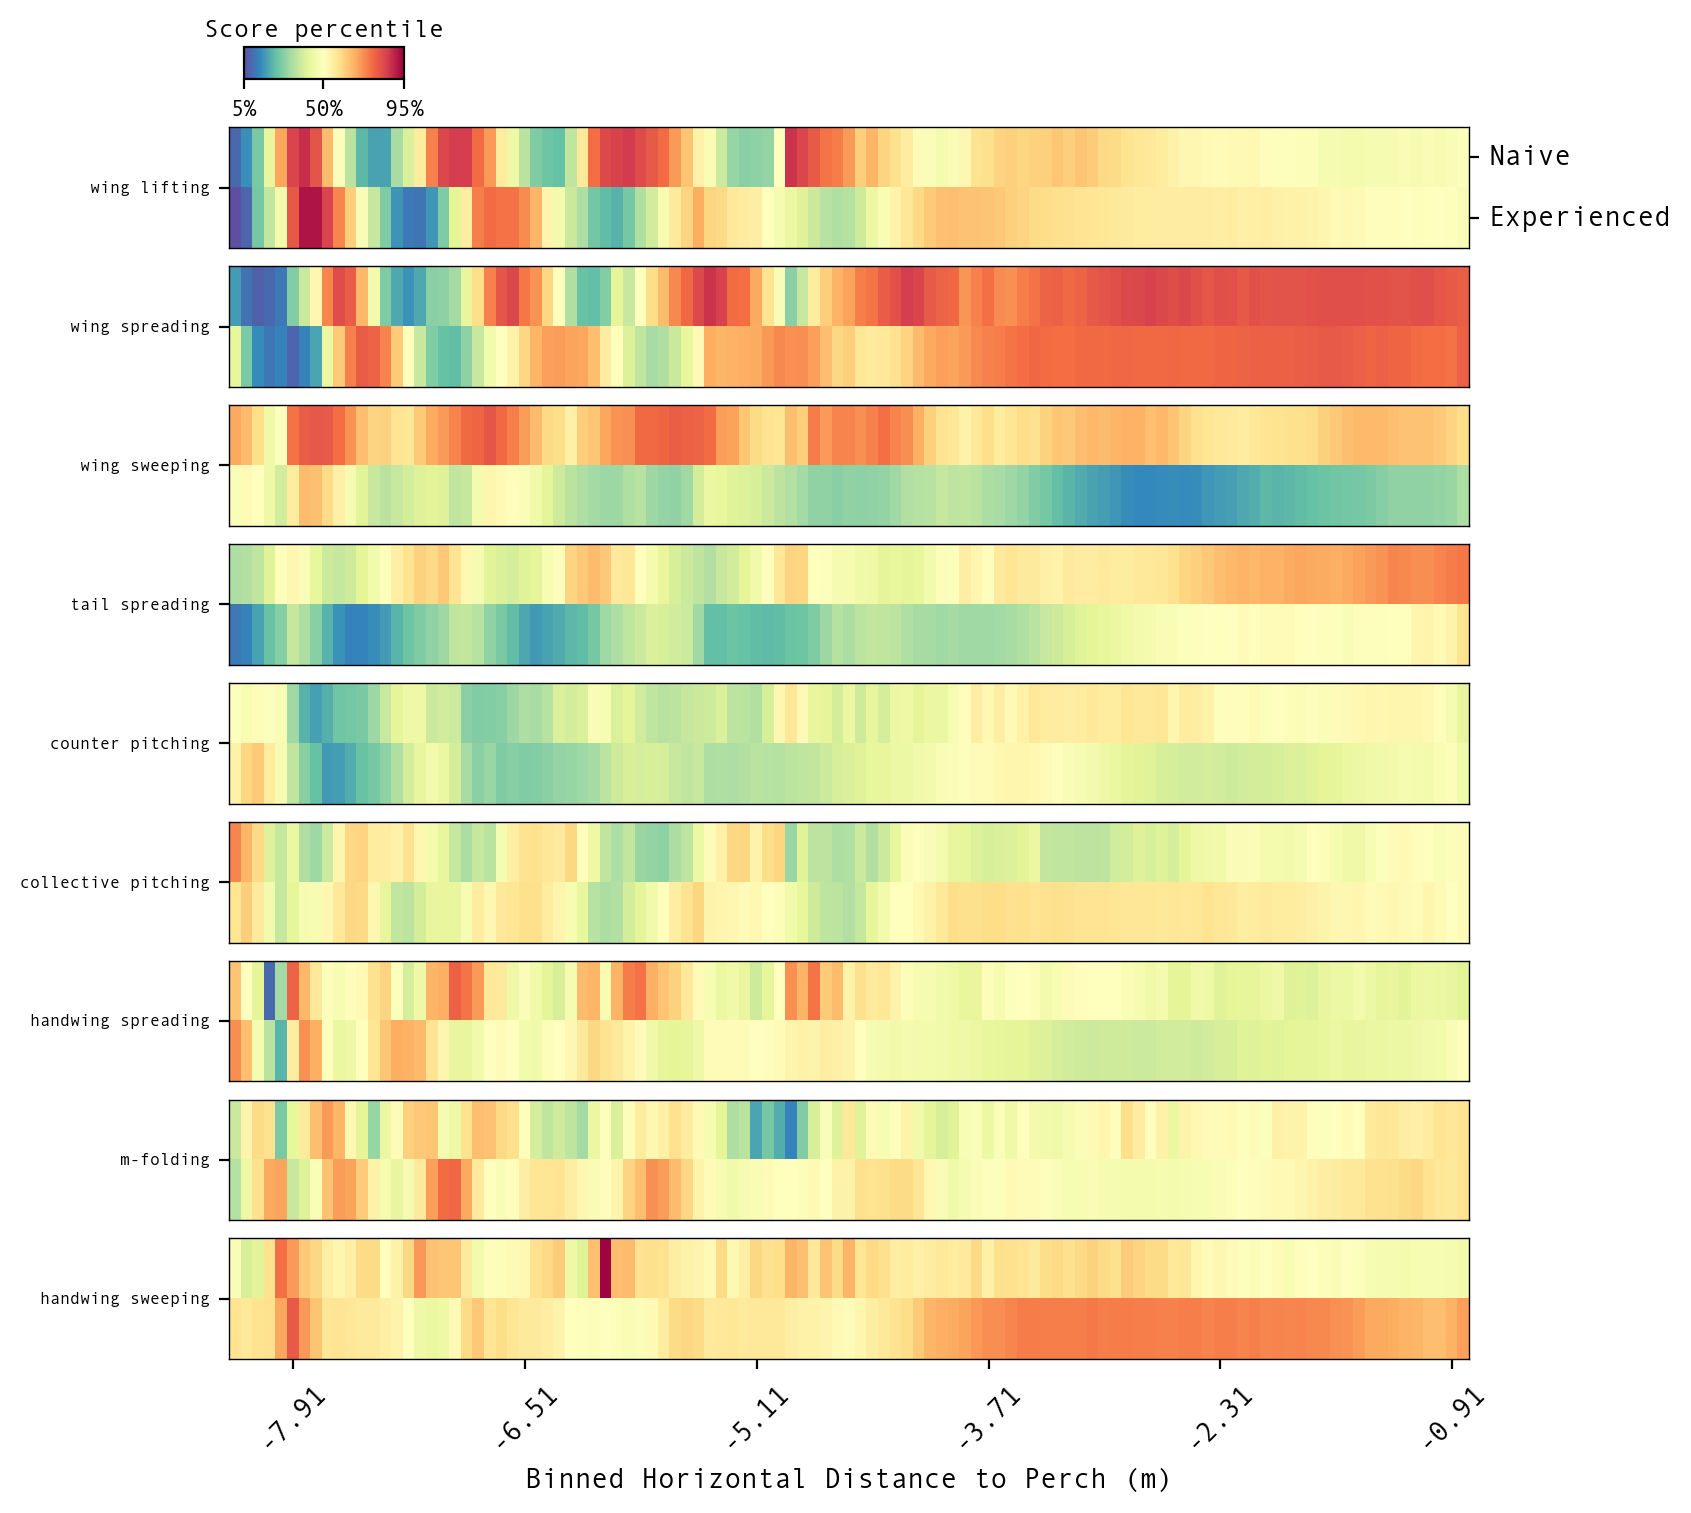

In [5]:
plt.close("all")
naive_hawks = ["Drogon", "Toothless"]

for hawk in naive_hawks:
    naive_df, exp_df, score_5, score_95 = prepare_heatmap_comparison(
        scores_df,
        reference_filters={"hawkname": hawk},
        condition1={"obstacle": 0, "perchDist": 9, "year": 2017, "hawkname": hawk},
        condition2={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": hawk, "IMU": 0},
    )
    print(f"--- {hawk}: naive vs experienced ---")
    plot_difference_exp_scores_heatmap(
        exp_df, "Experienced", naive_df, "Naive", PC_cols, score_5, score_95
    )

## Heatmap Comparisons — Drogon vs Rhaegal (Naive)

Drogon and Rhaegal are brothers, both recorded as naive juveniles (2017). Comparing their morphing patterns reveals individual differences in flight style at a similar developmental stage.

Condition 1: Number of frames: 14550; Number of flights: 76
Condition 2: Number of frames: 28392; Number of flights: 114
--- Drogon vs Rhaegal (both naive) ---


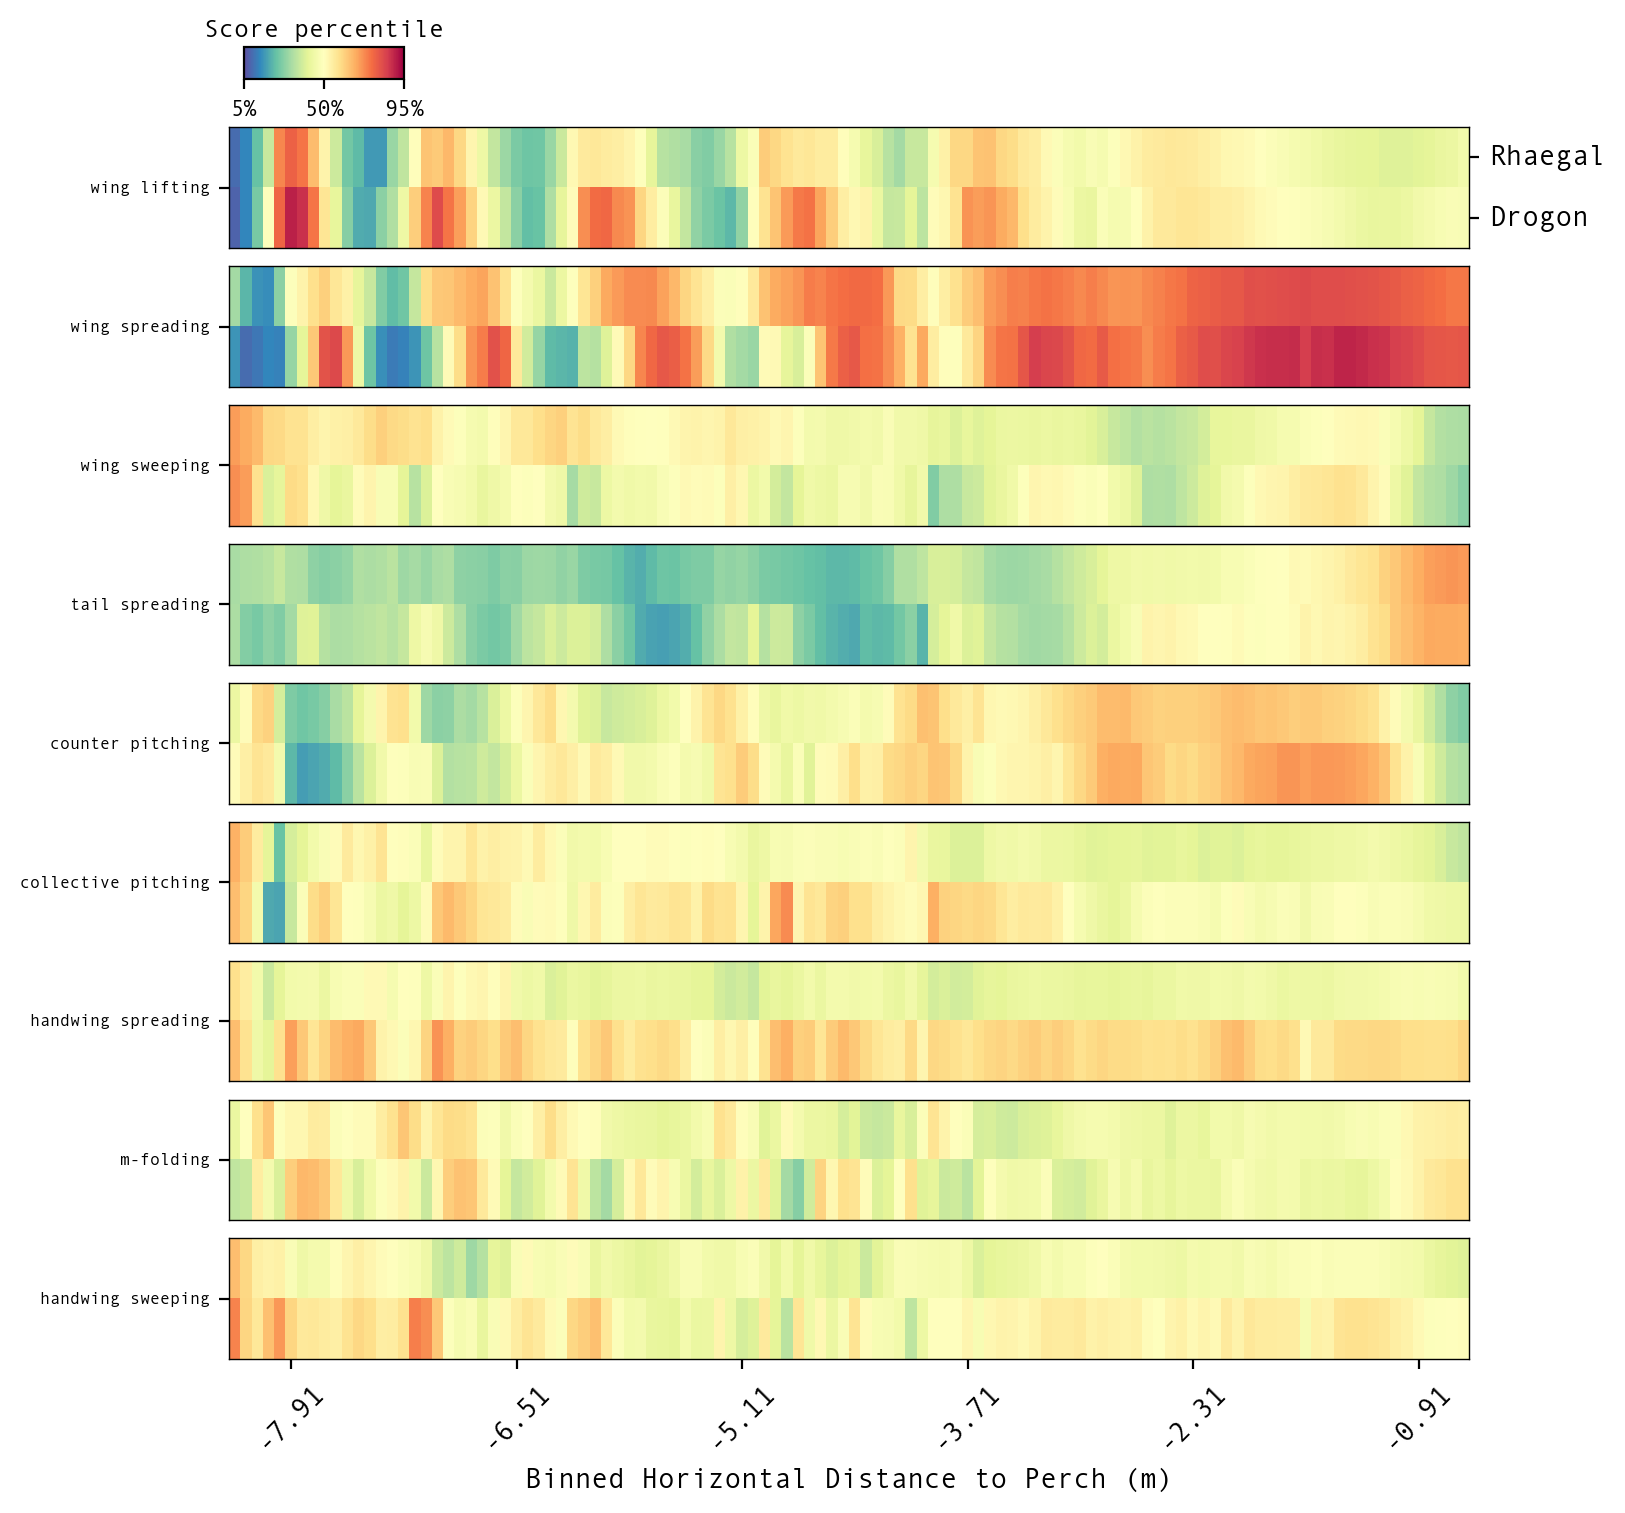

<Axes: xlabel='Binned Horizontal Distance to Perch (m)'>

In [6]:
plt.close("all")

drogon_df, rhaegal_df, score_5, score_95 = prepare_heatmap_comparison(
    scores_df,
    reference_filters={"year": 2017},
    condition1={"obstacle": 0, "perchDist": 9, "year": 2017, "hawkname": "Drogon"},
    condition2={"obstacle": 0, "perchDist": 9, "year": 2017, "hawkname": "Rhaegal"},
)
print("--- Drogon vs Rhaegal (both naive) ---")
plot_difference_exp_scores_heatmap(
    drogon_df, "Drogon", rhaegal_df, "Rhaegal", PC_cols, score_5, score_95
)

Condition 1: Number of frames: 23456; Number of flights: 67
Condition 2: Number of frames: 15530; Number of flights: 66
--- Toothless vs Ruby (both experienced) ---


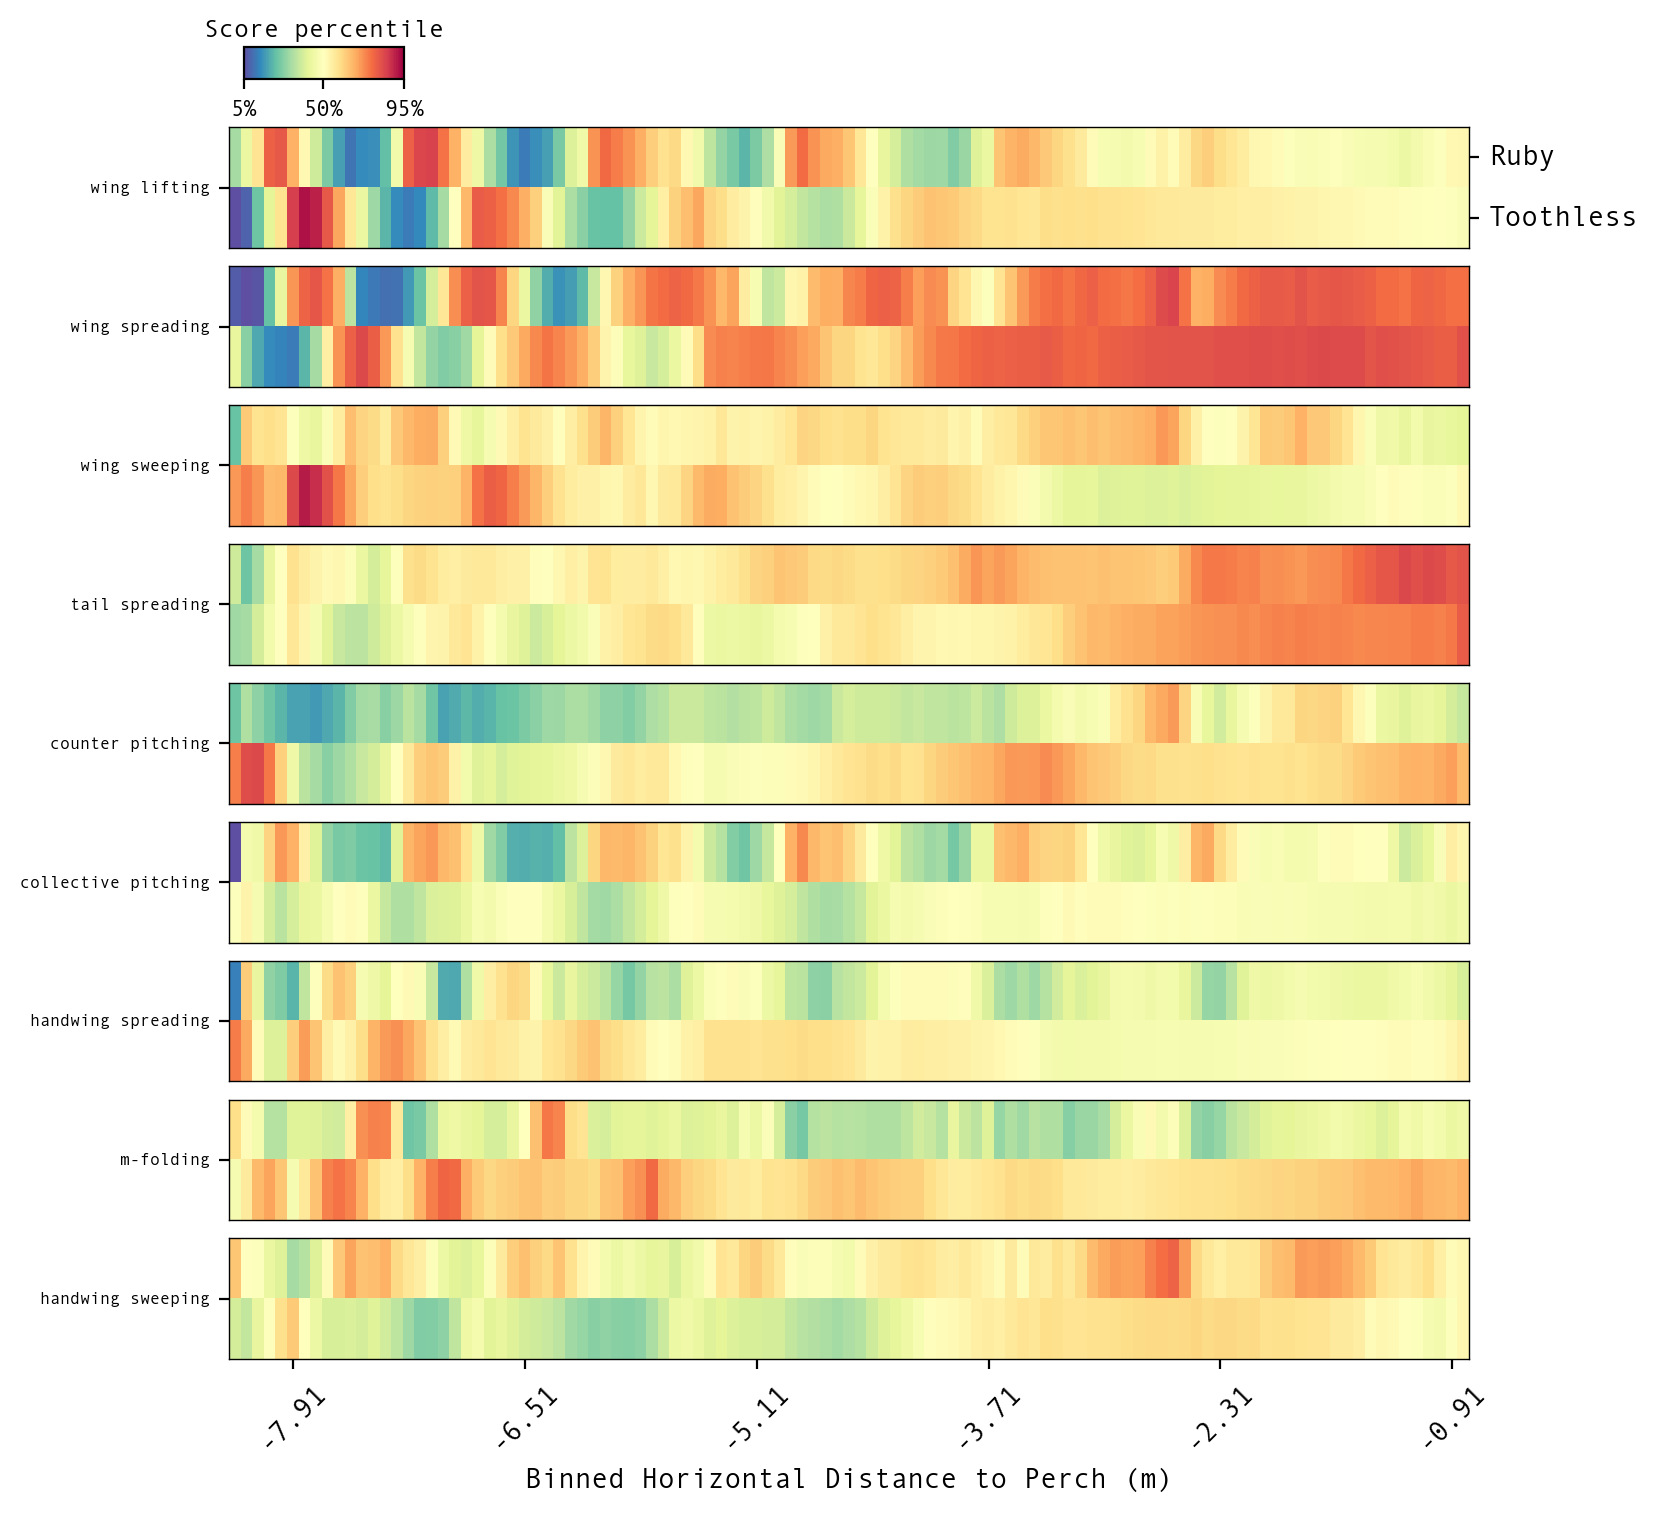

<Axes: xlabel='Binned Horizontal Distance to Perch (m)'>

In [7]:
plt.close("all")

toothless_df, ruby_df, score_5, score_95 = prepare_heatmap_comparison(
    scores_df,
    reference_filters={"year": 2020},
    condition1={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": "Toothless"},
    condition2={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": "Ruby"},
)
print("--- Toothless vs Ruby (both experienced) ---")
plot_difference_exp_scores_heatmap(
    toothless_df, "Toothless", ruby_df, "Ruby", PC_cols, score_5, score_95
)

## Summary

The heatmaps reveal individual-level morphing patterns across conditions:

- **Obstacle flights** introduce visible perturbations in sweep and pitching modes, with hawk-specific response patterns.
- **Added weight** produces subtle shifts in the dominant modes, consistent with minor adjustments to compensate for the additional mass.
- **Experience** changes the temporal structure of morphing — experienced hawks show more consistent wingbeat timing and cleaner transitions between flight phases.
- **Within- vs across-individual variation:** Within-individual variation is substantial but markedly smaller than across-individual differences, confirming that each hawk has a characteristic morphing signature.

> **Caveat (per §14):** These heatmaps provide a closer look at individual flight behaviour for consistent behaviours. As within- and across-individual variation is high, the heatmaps do not represent stereotyped generalisable behaviours and are not useful for comparison with highly variable flights. More advanced methods would be required to account for variable wingbeat frequencies and to compare rigorously across individuals.

---

## References

- KleinHeerenbrink, M., France, L. A., Brighton, C. H. & Taylor, G. K. (2022). Optimization of avian perching manoeuvres. *Nature*, 607, 91–96.